# Proyecto: Serpientes y Escaleras como Cadena de Markov
## Objetivo A: Construcción de la Matriz de Transición

En este cuaderno, modelaremos el juego de Serpientes y Escaleras como un proceso estocástico, específicamente una **Cadena de Markov de Tiempo Discreto**. 

### Definición del Espacio de Estados
Nuestro espacio de estados $S$ está compuesto por las 50 casillas del tablero: $S = \{1, 2, ..., 50\}$. En Python, representaremos esto con índices del 0 al 49.

### Pasos Teóricos para Construir la Matriz
Para construir la matriz de transición $P$ de 50x50, donde cada elemento $P_{i,j}$ representa la probabilidad de terminar el turno en la casilla $j$ dado que se empezó en la casilla $i$, seguimos estas reglas:

1. **Transiciones Estándar y Saltos:** Si tiramos un dado de 6 caras, cada cara tiene una probabilidad de $1/6$. Si el destino contiene una base de escalera o cabeza de serpiente, el jugador salta inmediatamente al destino final.
2. **Llegada Exacta:** Si desde la casilla actual el dado dicta un movimiento que sobrepasa el estado 50, el movimiento es inválido y el jugador se queda en la casilla actual (probabilidad de rebote).
3. **Encadenamiento de Partidas:** Si un jugador está en la casilla 50 (índice 49), su siguiente turno lo llevará obligatoriamente a la casilla 1 (índice 0). Por lo tanto, $P_{50,1} = 1.0$.
4. **La Regla del 6 (Turnos Compuestos):** Si sale un 6 y no se cae en una trampa, el jugador repite el turno. Esto significa que un "turno" puede consistir en múltiples tiradas. Para resolver esto matemáticamente, dividimos las probabilidades en dos matrices:
   * **Matriz $A$**: Probabilidades de tiradas que *terminan* el turno (sacar 1-5, o sacar 6 y caer en trampa/escalera).
   * **Matriz $B$**: Probabilidades de tiradas que *continúan* el turno (sacar 6 y no caer en trampa).
   
La matriz de transición final por turno se calcula sumando la serie infinita de posibles tiradas extras: $P = A + BA + B^2A + ...$, lo cual converge a la ecuación exacta:
$$P = (I - B)^{-1} A$$

In [3]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

# Agregamos la ruta del proyecto para poder importar nuestros scripts
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.board import Board
from src.markov import build_transition_matrix

# 1. Instanciamos el tablero con nuestras reglas
board = Board("../config/board_config.yaml")

# 2. Construimos la Matriz de Transición P
P = build_transition_matrix(board)

print(f"Forma de la Matriz P: {P.shape}")
print(f"¿La fila 0 (casilla 1) suma 1.0? -> {np.sum(P[0, :]):.2f}")
print(f"Probabilidad de ir de la casilla 50 a la 1: {P[49, 0]:.2f}")

Forma de la Matriz P: (50, 50)
¿La fila 0 (casilla 1) suma 1.0? -> 1.00
Probabilidad de ir de la casilla 50 a la 1: 1.00


### Visualización de la Matriz de Transición
Para entender cómo se comporta el juego, graficaremos la matriz $P$ utilizando un mapa de calor (Heatmap). 
En este gráfico:
- El eje Y representa el estado de origen (casilla actual).
- El eje X representa el estado de destino (casilla siguiente).
- El color indica la probabilidad de transición (colores más claros = mayor probabilidad).

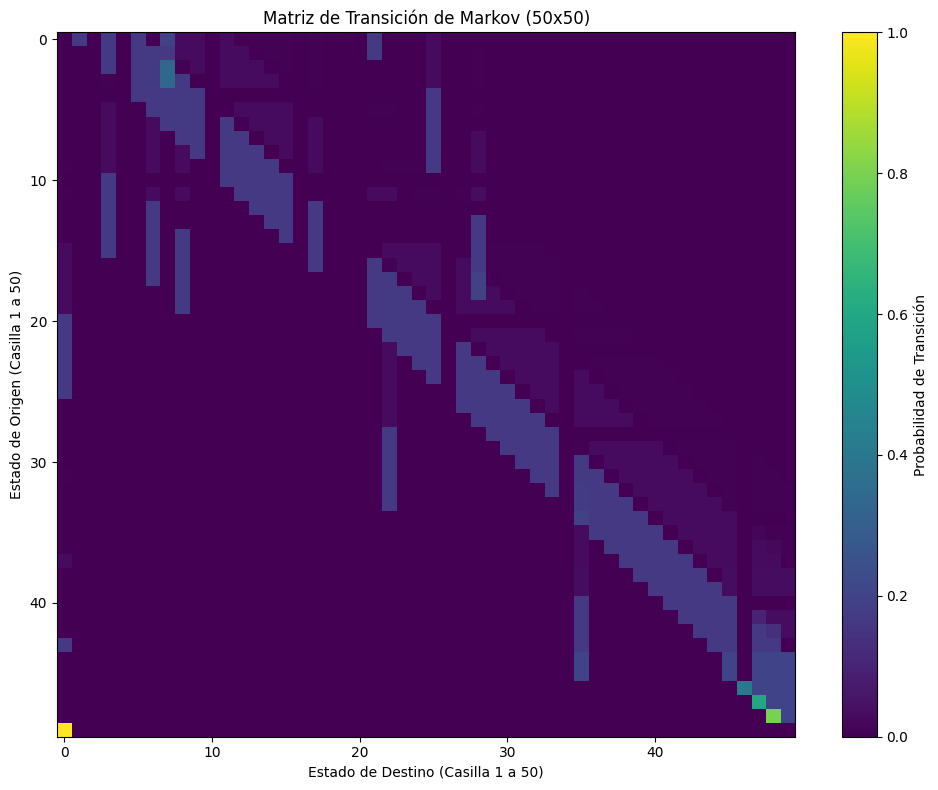

In [4]:
plt.figure(figsize=(10, 8))
# Usamos un mapa de calor para visualizar las probabilidades
plt.imshow(P, cmap='viridis', aspect='auto', interpolation='nearest')
plt.colorbar(label='Probabilidad de Transición')

plt.title('Matriz de Transición de Markov (50x50)')
plt.xlabel('Estado de Destino (Casilla 1 a 50)')
plt.ylabel('Estado de Origen (Casilla 1 a 50)')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Conclusiones Teóricas de la Matriz de Transición

Al observar el mapa de calor de la matriz $P$, podemos confirmar visualmente que nuestro modelo captura todas las reglas del juego:

1. **Banda de Transición y Regla del 6:** La matriz presenta una banda diagonal superior. Esta representa el avance natural del dado. La banda no se corta abruptamente en 5 casillas, sino que presenta un decaimiento exponencial hacia la derecha. Esto evidencia matemáticamente la regla de repetir turno al sacar un 6, permitiendo transiciones a estados lejanos en un solo turno compuesto.
2. **Serpientes y Escaleras (Discontinuidades):** Se observan puntos de alta probabilidad aislados de la diagonal. Los puntos situados a la derecha de la banda principal corresponden a las escaleras (saltos hacia adelante), mientras que los situados a la izquierda corresponden a las serpientes (retrocesos).
3. **Absorción y Rebote:** En los últimos estados (esquina inferior derecha), la diagonal principal toma valores mayores a cero ($P_{i,i} > 0$). Esto demuestra la regla de llegada exacta: si el jugador saca un número mayor al necesario para llegar a 50, se queda en su posición actual.
4. **Encadenamiento (Irreducibilidad):** Existe un punto de probabilidad máxima ($P = 1.0$) en la coordenada (49, 0), que corresponde a la transición de la casilla 50 a la casilla 1. Esto convierte a nuestra Cadena de Markov en un proceso *irreducible* y *positivo recurrente*, lo que garantiza la existencia de un vector estacionario único $\pi$.